In [1]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

ds = xr.concat(datasets, dim='station')

File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset> Size: 58MB
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 8B ...
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B ...
    longitude            float64 8B ...
    station_latitude     float64 8B ...
    station_longitude    float64 8B ...
    year                 (valid_time) int64 6MB ...
Data variables: (12/15)
    u10                  (valid_time) float32 3MB ...
    v10                  (valid_time) float32 3MB ...
    d2m                  (valid_time) float32 3MB ...
    t2m                  (valid_time) float32 3MB ...
    msl                  (valid_time) float32 3MB ...
    sst                  (valid_time) float32 3MB ...
    ...                   ...
    mwp                  (valid_time) float32 3MB ...
    swh                  (valid_time) float32 3MB ...
    sea_level     

In [2]:
ds = xr.concat(datasets, dim='station')

In [32]:
import pandas as pd
df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
df = df[~df["cluster"].isin([0, 5])].copy()
# Get sorted unique remaining clusters
unique_clusters = sorted(df["cluster"].unique())

# Build mapping → start numbering from 1
cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}

# Apply remapping
df["cluster"] = df["cluster"].map(cluster_map)

In [17]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ds = xr.concat(datasets, dim="station")

var = "residual"
time_dim = "valid_time"
station_dim = "station"

# 1) valid observations
valid = ds[var].notnull()

# 2) count valid observations per year and station
coverage = valid.groupby(f"{time_dim}.year").sum(time_dim)

# 3) active if there is at least one valid observation in that year
active = coverage > 0   # dims: year, station

# 4) first and last active year per station
years = active["year"].values
station_ids = ds[station_dim].values

rows = []
for i, st in enumerate(station_ids):
    vals = active.isel({station_dim: i}).values
    active_years = years[vals]
    if len(active_years) > 0:
        rows.append({
            "station": str(st),
            "start": int(active_years.min()),
            "end": int(active_years.max()),
            "n_years": int(len(active_years)),
        })

station_periods = pd.DataFrame(rows).sort_values(["start", "end"]).reset_index(drop=True)

print(station_periods.head())
print(f"{len(station_periods)} stations with valid {var} data")

  station  start   end  n_years
0     140   1950  1990       39
1     102   1950  2013       64
2     103   1950  2024       75
3       4   1950  2024       75
4      42   1950  2024       75
279 stations with valid residual data


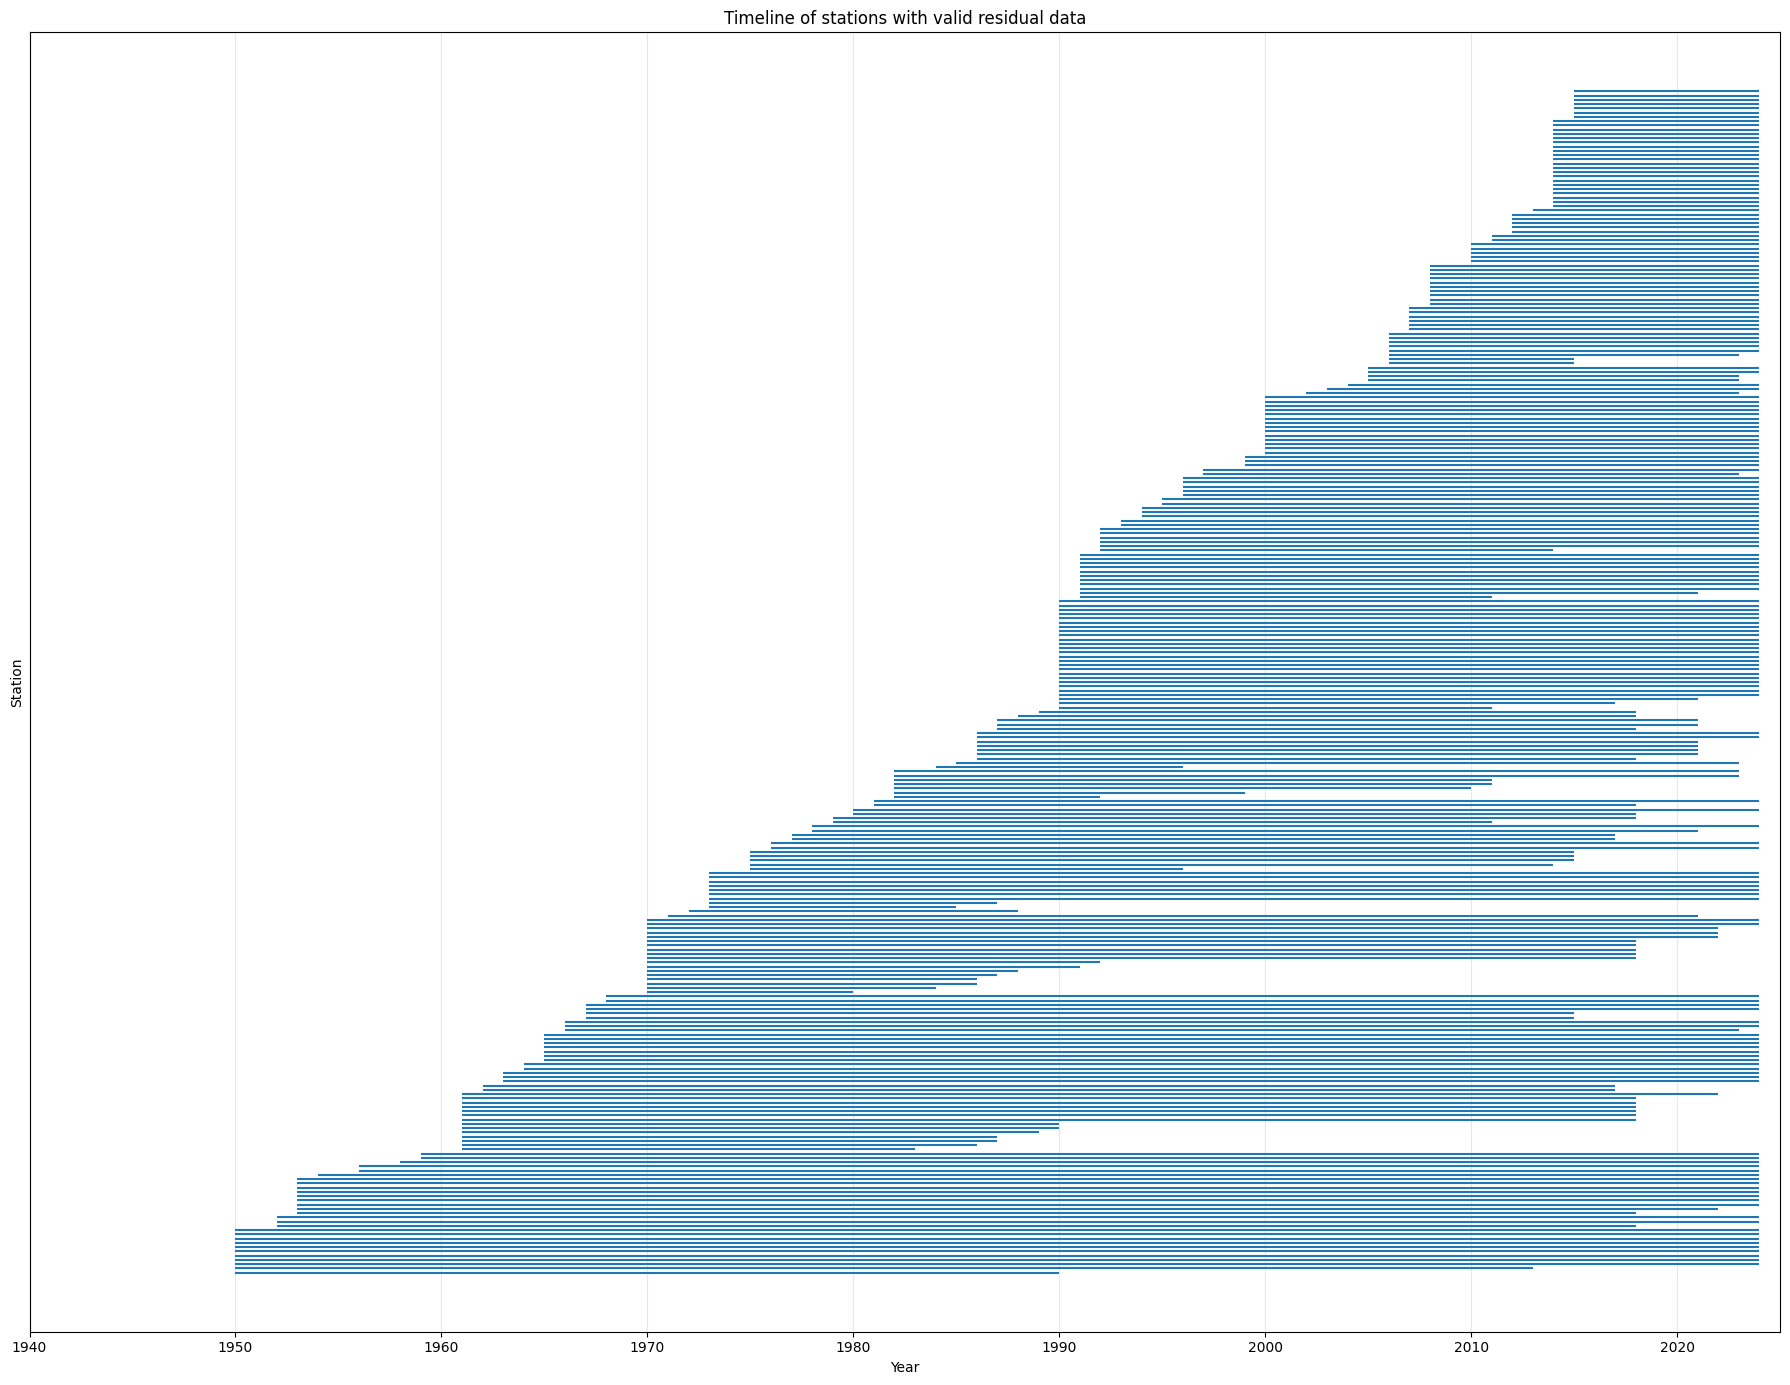

In [20]:
fig_height = max(8, len(station_periods) * 0.05)
fig, ax = plt.subplots(figsize=(18, fig_height))

for y, row in station_periods.iterrows():
    ax.hlines(
        y=y,
        xmin=row["start"],
        xmax=row["end"],
        linewidth=1.5
    )

ax.set_xlim(1940, 2025)
ax.set_xlabel("Year")
ax.set_ylabel("Station")
ax.set_title(f"Timeline of stations with valid {var} data")

# show labels only if manageable
if len(station_periods) <= 80:
    ax.set_yticks(range(len(station_periods)))
    ax.set_yticklabels(station_periods["station"])
else:
    ax.set_yticks([])

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
valid = ds["residual"].notnull()

coverage = valid.groupby("valid_time.year").sum("valid_time")

stations_per_year = (coverage > 0).sum("station").to_pandas()

AttributeError: 'DataArray' object has no attribute 'index'

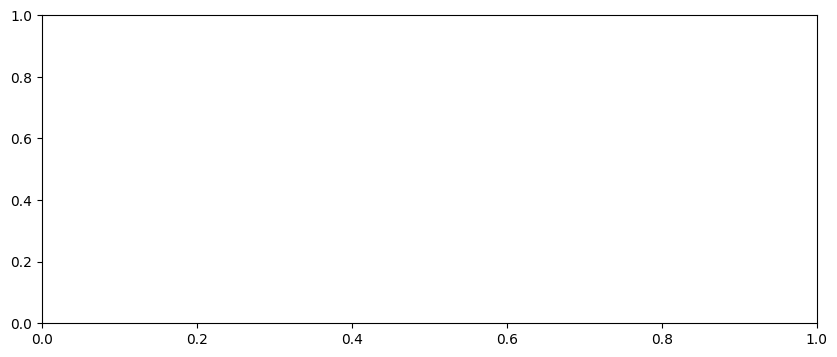

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(stations_per_year.index, stations_per_year.values, lw=2)

ax.set_xlabel("Year")
ax.set_ylabel("Active stations")
ax.set_title("Station coverage over time")

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

# -----------------------------
# config
# -----------------------------
TARGET_VAR = "residual"
N_STATIONS = 295
RESAMPLE_RULE = "2M"   # 2-month block maxima
MIN_VALID_POINTS = 10
MIN_BLOCKS = 5

# -----------------------------
# choose variable if needed
# -----------------------------
if TARGET_VAR not in ds.data_vars:
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}'")
            break
    else:
        raise ValueError("No numeric data variable found.")

# -----------------------------
# helpers
# -----------------------------
def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

def kuiper_statistic(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)
    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)
    F_mod = cdf_func(x)
    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

def _length_years_from_times(time_values):
    t = pd.to_datetime(np.asarray(time_values))
    t = t[~pd.isnull(t)]
    if len(t) < 2:
        return np.nan
    span_days = (t.max() - t.min()) / np.timedelta64(1, "D")
    return span_days / 365.25

# -----------------------------
# fit one GEV per station
# -----------------------------
stations = np.array(ds["station"].values)[:N_STATIONS]
fit_rows = []

for s in stations:
    da = ds[TARGET_VAR].sel(station=s)

    try:
        tdim = _time_dim(da)
    except Exception as e:
        print(f"Skipping station {s}: no time dim ({e})")
        continue

    da = da.where(np.isfinite(da), drop=True)

    if da.size < MIN_VALID_POINTS:
        print(f"Skipping station {s}: too few valid points")
        continue

    # catalogue length from original cleaned series
    try:
        station_length_years = _length_years_from_times(da[tdim].values)
    except Exception as e:
        print(f"Skipping station {s}: could not compute length ({e})")
        continue

    # block maxima
    try:
        r = da.resample({tdim: RESAMPLE_RULE})
        da_max = r.max()
    except Exception as e:
        print(f"Skipping station {s}: resample failed ({e})")
        continue

    valid = np.isfinite(da_max.values)
    x = np.asarray(da_max.values[valid]).ravel()

    if x.size < MIN_BLOCKS:
        print(f"Skipping station {s}: too few block maxima")
        continue

    try:
        gev_params = st.genextreme.fit(x)
        c, loc, scale = gev_params

        def gev_cdf(z):
            return st.genextreme.cdf(z, c, loc=loc, scale=scale)

        ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)
        kuiper = kuiper_statistic(x, gev_cdf)
        r2 = r2_cdf_fit(x, gev_cdf)

    except Exception as e:
        print(f"Skipping station {s}: GEV fit failed ({e})")
        continue

    fit_rows.append({
        "station": int(s),
        "length_years": station_length_years,
        "n_blocks": int(x.size),
        "gev_c": c,
        "gev_loc": loc,
        "gev_scale": scale,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "kuiper": kuiper,
        "r2_cdf": r2,
    })

df_fit = pd.DataFrame(fit_rows)

if df_fit.empty:
    raise RuntimeError("No successful station fits.")

print(df_fit.head())
print(f"Number of fitted stations: {len(df_fit)}")

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 110: too few valid points
Skipping station 112: too few valid points
Skipping station 113: too few valid points


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 143: too few valid points
Skipping station 145: too few valid points


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

...

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 557: too few valid points
Skipping station 558: too few valid points
Skipping station 564: too few valid points


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

Skipping station 96: too few valid points
   station  length_years  n_blocks     gev_c   gev_loc  gev_scale   ks_stat  \
0        1     66.254962       399  0.019241  0.396674   0.154282  0.024866   
1       10     65.705681       237  0.008878  0.396981   0.213112  0.039548   
2      102     63.915013       377  0.091471  0.382442   0.133961  0.028606   
3      103     75.000570       448  0.182677  0.416630   0.338177  0.198556   
4      104     35.000342       208  0.207224  0.355725   0.397805  0.227405   

      ks_pvalue    kuiper    r2_cdf  
0  9.608442e-01  0.049478  0.998840  
1  8.378220e-01  0.076243  0.996154  
2  9.083926e-01  0.053212  0.998736  
3  5.918326e-16  0.348877  0.833575  
4  6.182796e-10  0.426216  0.779609  
Number of fitted stations: 279


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


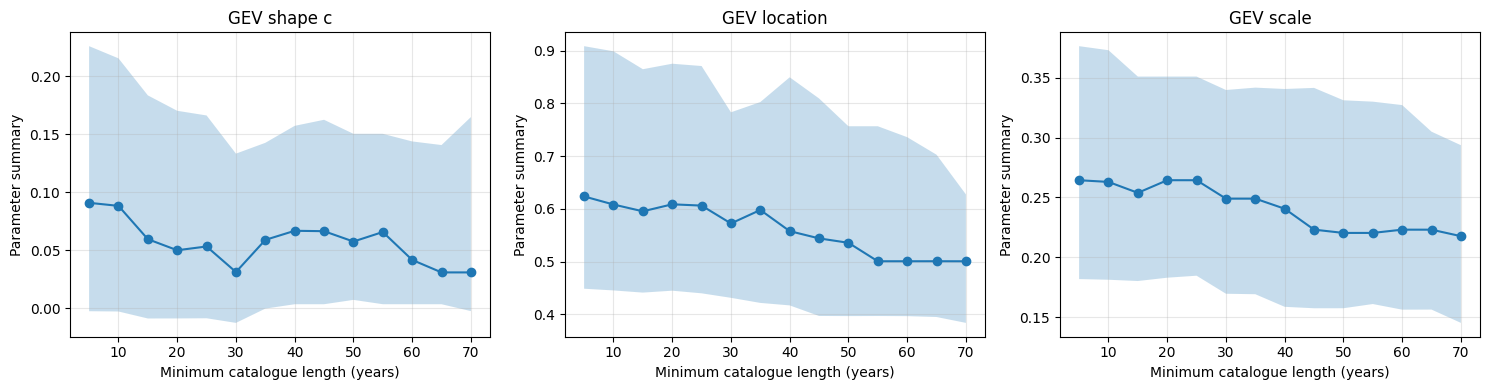

In [23]:
# -------------------------------------
# stability vs minimum catalogue length
# -------------------------------------
thresholds = np.arange(5, 81, 5)  # years

stab_rows = []

for Lmin in thresholds:
    sub = df_fit[df_fit["length_years"] >= Lmin].copy()

    if len(sub) < 5:
        continue

    stab_rows.append({
        "min_length": Lmin,
        "n_stations": len(sub),

        "gev_c_median": sub["gev_c"].median(),
        "gev_c_q25": sub["gev_c"].quantile(0.25),
        "gev_c_q75": sub["gev_c"].quantile(0.75),

        "gev_loc_median": sub["gev_loc"].median(),
        "gev_loc_q25": sub["gev_loc"].quantile(0.25),
        "gev_loc_q75": sub["gev_loc"].quantile(0.75),

        "gev_scale_median": sub["gev_scale"].median(),
        "gev_scale_q25": sub["gev_scale"].quantile(0.25),
        "gev_scale_q75": sub["gev_scale"].quantile(0.75),
    })

stab = pd.DataFrame(stab_rows)

if stab.empty:
    raise RuntimeError("No thresholds had enough stations.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

plot_specs = [
    ("gev_c_median", "gev_c_q25", "gev_c_q75", "GEV shape c"),
    ("gev_loc_median", "gev_loc_q25", "gev_loc_q75", "GEV location"),
    ("gev_scale_median", "gev_scale_q25", "gev_scale_q75", "GEV scale"),
]

for ax, (med, q25, q75, title) in zip(axes, plot_specs):
    x = stab["min_length"].values
    y = stab[med].values
    y1 = stab[q25].values
    y2 = stab[q75].values

    ax.plot(x, y, marker="o")
    ax.fill_between(x, y1, y2, alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel("Minimum catalogue length (years)")
    ax.set_ylabel("Parameter summary")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

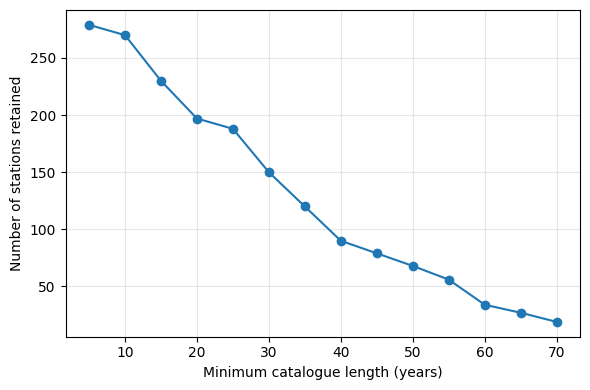

In [24]:
plt.figure(figsize=(6, 4))
plt.plot(stab["min_length"], stab["n_stations"], marker="o")
plt.xlabel("Minimum catalogue length (years)")
plt.ylabel("Number of stations retained")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

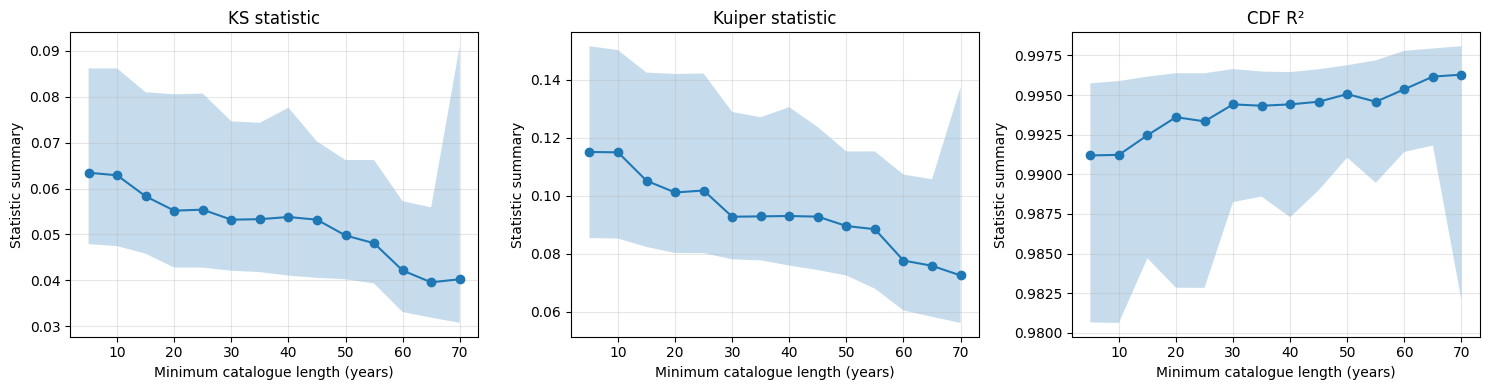

In [25]:
gof_rows = []

for Lmin in thresholds:
    sub = df_fit[df_fit["length_years"] >= Lmin].copy()

    if len(sub) < 5:
        continue

    gof_rows.append({
        "min_length": Lmin,
        "n_stations": len(sub),

        "ks_stat_median": sub["ks_stat"].median(),
        "ks_stat_q25": sub["ks_stat"].quantile(0.25),
        "ks_stat_q75": sub["ks_stat"].quantile(0.75),

        "kuiper_median": sub["kuiper"].median(),
        "kuiper_q25": sub["kuiper"].quantile(0.25),
        "kuiper_q75": sub["kuiper"].quantile(0.75),

        "r2_cdf_median": sub["r2_cdf"].median(),
        "r2_cdf_q25": sub["r2_cdf"].quantile(0.25),
        "r2_cdf_q75": sub["r2_cdf"].quantile(0.75),
    })

gof = pd.DataFrame(gof_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

plot_specs = [
    ("ks_stat_median", "ks_stat_q25", "ks_stat_q75", "KS statistic"),
    ("kuiper_median", "kuiper_q25", "kuiper_q75", "Kuiper statistic"),
    ("r2_cdf_median", "r2_cdf_q25", "r2_cdf_q75", "CDF R²"),
]

for ax, (med, q25, q75, title) in zip(axes, plot_specs):
    x = gof["min_length"].values
    y = gof[med].values
    y1 = gof[q25].values
    y2 = gof[q75].values

    ax.plot(x, y, marker="o")
    ax.fill_between(x, y1, y2, alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel("Minimum catalogue length (years)")
    ax.set_ylabel("Statistic summary")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Hold-out per station

In [26]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

TARGET_VAR = "residual"
RESAMPLE_RULE = "2M"
STEP_YEARS = 10
MAX_YEARS = 80

def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station","stations")]
    return candidates[0]

stations = ds.station.values[:295]

station_results = []

for s in stations:

    da = ds[TARGET_VAR].sel(station=s)

    try:
        tdim = _time_dim(da)
    except:
        continue

    da = da.where(np.isfinite(da), drop=True)

    if da.size < 50:
        continue

    time = pd.to_datetime(da[tdim].values)
    start_time = time.min()

    for yrs in range(STEP_YEARS, MAX_YEARS+1, STEP_YEARS):

        end_time = start_time + pd.DateOffset(years=yrs)

        da_sub = da.sel({tdim: slice(start_time, end_time)})

        if da_sub.size < 20:
            continue

        try:
            da_max = da_sub.resample({tdim: RESAMPLE_RULE}).max()
        except:
            continue

        x = da_max.values[np.isfinite(da_max.values)]

        if len(x) < 5:
            continue

        try:
            c, loc, scale = st.genextreme.fit(x)
        except:
            continue

        station_results.append({
            "station": int(s),
            "years_used": yrs,
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale
        })

df_stability = pd.DataFrame(station_results)

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

In [28]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st

# -----------------------------
# config
# -----------------------------
TARGET_VAR = "residual"
N_STATIONS = 295
RESAMPLE_RULE = "2M"     # 2-month block maxima
STEP_YEARS = 10
MIN_VALID_POINTS = 10
MIN_BLOCKS = 5

# -----------------------------
# choose variable if needed
# -----------------------------
if TARGET_VAR not in ds.data_vars:
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}'")
            break
    else:
        raise ValueError("No numeric data variable found.")

# -----------------------------
# helpers
# -----------------------------
def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

def _record_length_years(time_values):
    t = pd.to_datetime(np.asarray(time_values))
    t = t[~pd.isnull(t)]
    if len(t) < 2:
        return np.nan
    return (t.max() - t.min()) / np.timedelta64(1, "D") / 365.25

stations = np.array(ds["station"].values)[:N_STATIONS]

rows = []

for s in stations:
    da = ds[TARGET_VAR].sel(station=s)

    try:
        tdim = _time_dim(da)
    except Exception:
        continue

    da = da.where(np.isfinite(da), drop=True)

    if da.size < MIN_VALID_POINTS:
        continue

    try:
        times = pd.to_datetime(da[tdim].values)
        t0 = pd.Timestamp(times.min())
        total_years = _record_length_years(times)
    except Exception:
        continue

    if not np.isfinite(total_years) or total_years < STEP_YEARS:
        continue

    # fit progressively longer prefixes of the record
    max_step = int(np.floor(total_years / STEP_YEARS)) * STEP_YEARS

    for yrs in range(STEP_YEARS, max_step + 1, STEP_YEARS):
        t1 = t0 + pd.DateOffset(years=yrs)

        try:
            da_sub = da.sel({tdim: slice(t0, t1)})
        except Exception:
            continue

        da_sub = da_sub.where(np.isfinite(da_sub), drop=True)

        if da_sub.size < MIN_VALID_POINTS:
            continue

        try:
            da_max = da_sub.resample({tdim: RESAMPLE_RULE}).max()
        except Exception:
            continue

        x = np.asarray(da_max.values)
        x = x[np.isfinite(x)]

        if x.size < MIN_BLOCKS:
            continue

        try:
            c, loc, scale = st.genextreme.fit(x)
        except Exception:
            continue

        rows.append({
            "station": int(s),
            "years_used": int(yrs),
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "n_blocks": int(x.size),
            "total_years": float(total_years),
        })

df_stab = pd.DataFrame(rows)

if df_stab.empty:
    raise RuntimeError("No station stability fits were produced.")

print(df_stab.head())
print(f"Stations contributing: {df_stab['station'].nunique()}")

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: Futu

   station  years_used     gev_c   gev_loc  gev_scale  n_blocks  total_years
0        1          10 -0.000114  0.469840   0.151726        61    66.254962
1        1          20 -0.006923  0.442511   0.144408       121    66.254962
2        1          30  0.049929  0.419357   0.159566       181    66.254962
3        1          40 -0.012319  0.411075   0.153329       241    66.254962
4        1          50 -0.005090  0.405223   0.152610       301    66.254962
Stations contributing: 270


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/groupers.py:487: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85480/1725225285.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


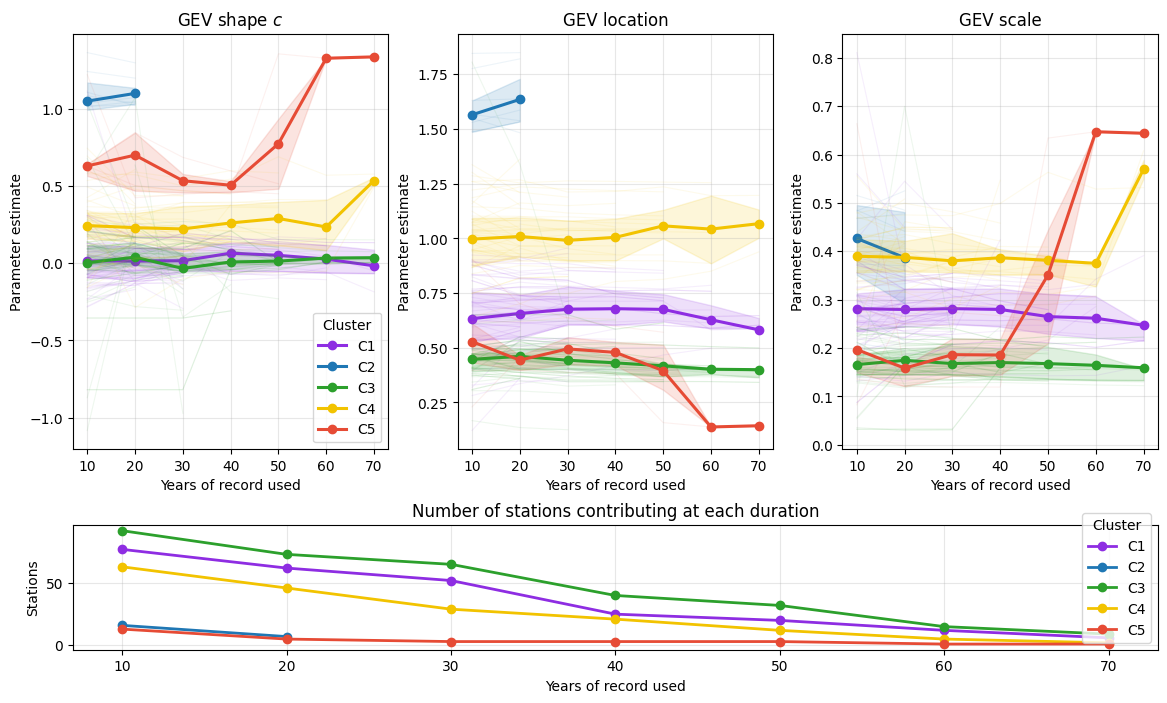

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# load and remap clusters
# -------------------------
df_cluster = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_7.csv")
df_cluster = df_cluster[~df_cluster["cluster"].isin([0, 5])].copy()

unique_clusters = sorted(df_cluster["cluster"].unique())
cluster_map = {old: new for new, old in enumerate(unique_clusters, start=1)}
df_cluster["cluster"] = df_cluster["cluster"].map(cluster_map)

# keep only needed columns
df_cluster = df_cluster[["station", "cluster"]].drop_duplicates()

# make sure station dtype matches
df_stab["station"] = df_stab["station"].astype(int)
df_cluster["station"] = df_cluster["station"].astype(int)

# -------------------------
# merge cluster info onto stability table
# -------------------------
df_stab_cl = df_stab.merge(df_cluster, on="station", how="inner")

if df_stab_cl.empty:
    raise RuntimeError("No overlap between df_stab stations and cluster table.")

# -------------------------
# cluster-wise summaries
# -------------------------
summary_cl = (
    df_stab_cl
    .groupby(["cluster", "years_used"])
    .agg(
        gev_c_mean=("gev_c", "mean"),
        gev_c_q25=("gev_c", lambda x: x.quantile(0.25)),
        gev_c_q75=("gev_c", lambda x: x.quantile(0.75)),

        gev_loc_mean=("gev_loc", "mean"),
        gev_loc_q25=("gev_loc", lambda x: x.quantile(0.25)),
        gev_loc_q75=("gev_loc", lambda x: x.quantile(0.75)),

        gev_scale_mean=("gev_scale", "mean"),
        gev_scale_q25=("gev_scale", lambda x: x.quantile(0.25)),
        gev_scale_q75=("gev_scale", lambda x: x.quantile(0.75)),

        n_stations=("station", "nunique"),
    )
    .reset_index()
)

# -------------------------
# plot
# -------------------------
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[4, 1.2], hspace=0.28, wspace=0.22)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_n = fig.add_subplot(gs[1, :])

specs = [
    ("gev_c", "gev_c_mean", "gev_c_q25", "gev_c_q75", "GEV shape $c$"),
    ("gev_loc", "gev_loc_mean", "gev_loc_q25", "gev_loc_q75", "GEV location"),
    ("gev_scale", "gev_scale_mean", "gev_scale_q25", "gev_scale_q75", "GEV scale"),
]

import matplotlib.colors as mcolors
import numpy as np

# Ensure clusters are integers and sorted
clusters = np.sort(df_stab_cl["cluster"].unique())
n_clusters = len(clusters)

base_colors = [
    "#8E2DE2",  # purple
    "#1F77B4",  # blue
    "#2CA02C",  # green
    "#F2C300",  # yellow
    "#E64B35",  # orange-red
]

colors = base_colors[:n_clusters]

cmap = mcolors.ListedColormap(colors)
bounds = np.arange(n_clusters + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Create cluster → color mapping
cluster_colours = {cl: colors[i] for i, cl in enumerate(clusters)}


clusters = sorted(df_stab_cl["cluster"].dropna().unique())

for ax, (col, mean_col, q25_col, q75_col, title) in zip(axes, specs):

    for cl in clusters:
        colour = cluster_colours[cl]
        gcl = df_stab_cl[df_stab_cl["cluster"] == cl].copy()
        scl = summary_cl[summary_cl["cluster"] == cl].copy()

        # faint station trajectories within this cluster
        for station_id, g in gcl.groupby("station"):
            g = g.sort_values("years_used")
            ax.plot(
                g["years_used"],
                g[col],
                alpha=0.08,
                color=colour,
                linewidth=0.8
            )

        # IQR envelope for this cluster
        ax.fill_between(
            scl["years_used"],
            scl[q25_col],
            scl[q75_col],
            color=colour,
            alpha=0.15
        )

        # mean trajectory for this cluster
        ax.plot(
            scl["years_used"],
            scl[mean_col],
            marker="o",
            color=colour,
            linewidth=2.2,
            label=f"C{cl}"
        )

    ax.set_title(title)
    ax.set_xlabel("Years of record used")
    ax.set_ylabel("Parameter estimate")
    ax.grid(alpha=0.3)

axes[0].legend(title="Cluster", loc="best")

# number of stations per cluster
for cl in clusters:
    colour = cluster_colours[cl]
    scl = summary_cl[summary_cl["cluster"] == cl].copy()
    ax_n.plot(
        scl["years_used"],
        scl["n_stations"],
        marker="o",
        linewidth=2.0,
        color=colour,
        label=f"C{cl}"
    )

ax_n.set_xlabel("Years of record used")
ax_n.set_ylabel("Stations")
ax_n.legend(title="Cluster", loc="best")
ax_n.set_title("Number of stations contributing at each duration")
ax_n.grid(alpha=0.3)

plt.tight_layout()
plt.show()

GEV parameters are robust to record length and cluster-dependent, with shape parameters close to zero across most regimes.

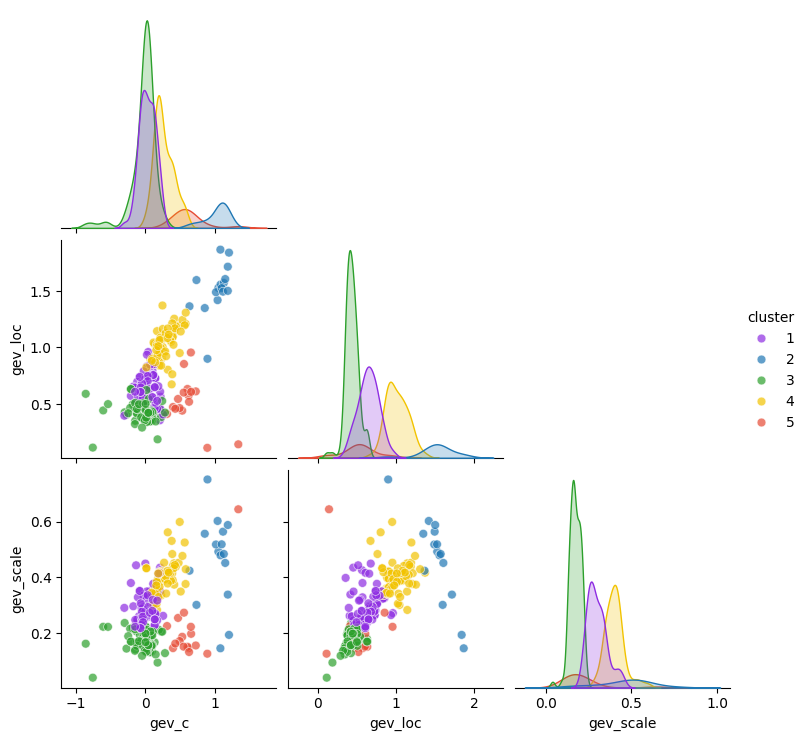

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["gev_c", "gev_loc", "gev_scale"]

sns.pairplot(
    df,
    vars=cols,
    hue="cluster",
    corner=True,
    palette=colors,
    plot_kws={"alpha":0.7, "s":40}
)

plt.show()

In [38]:
from sklearn.metrics import silhouette_score

X = df[["gev_c", "gev_loc", "gev_scale"]].values
labels = df["cluster"].values

score = silhouette_score(X, labels)

print("Silhouette score:", score)

Silhouette score: 0.3604433843759771


1
2
3
4
5


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85480/3168686975.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


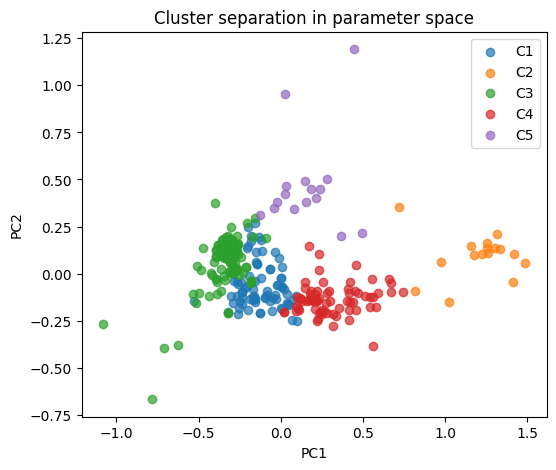

In [46]:
from sklearn.decomposition import PCA

X = df[["gev_c","gev_loc","gev_scale"]]

pca = PCA(n_components=2)
Xp = pca.fit_transform(X)

plt.figure(figsize=(6,5))

for cl in sorted(df["cluster"].unique()):
    print(cl)
    idx = df["cluster"] == cl
    colour = cluster_colours[cl]
    plt.scatter(
        Xp[idx,0],
        Xp[idx,1],
        label=f"C{cl}",
        cmap=colour,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Cluster separation in parameter space")
plt.show()

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X = df[["gev_c","gev_loc","gev_scale"]]
y = df["cluster"]

rf = RandomForestClassifier(n_estimators=500, random_state=0)

scores = cross_val_score(rf, X, y, cv=5)

print("Mean accuracy:", scores.mean())

Mean accuracy: 0.9567532467532468


# clusters are very distinct.

In [29]:
summary = (
    df_stab
    .groupby("years_used")
    .agg(
        gev_c_median=("gev_c", "median"),
        gev_c_q25=("gev_c", lambda x: x.quantile(0.25)),
        gev_c_q75=("gev_c", lambda x: x.quantile(0.75)),

        gev_loc_median=("gev_loc", "median"),
        gev_loc_q25=("gev_loc", lambda x: x.quantile(0.25)),
        gev_loc_q75=("gev_loc", lambda x: x.quantile(0.75)),

        gev_scale_median=("gev_scale", "median"),
        gev_scale_q25=("gev_scale", lambda x: x.quantile(0.25)),
        gev_scale_q75=("gev_scale", lambda x: x.quantile(0.75)),

        n_stations=("station", "nunique"),
    )
    .reset_index()
)

print(summary)

   years_used  gev_c_median  gev_c_q25  gev_c_q75  gev_loc_median  \
0          10      0.098307  -0.038974   0.268164        0.610976   
1          20      0.094811  -0.011640   0.191888        0.614173   
2          30      0.044352  -0.039623   0.144253        0.572714   
3          40      0.086975  -0.019617   0.171719        0.584746   
4          50      0.045032  -0.005202   0.139302        0.519146   
5          60      0.034470  -0.004744   0.128574        0.505287   
6          70      0.025925   0.000304   0.141788        0.499166   

   gev_loc_q25  gev_loc_q75  gev_scale_median  gev_scale_q25  gev_scale_q75  \
0     0.442450     0.902778          0.243149       0.173985       0.375282   
1     0.455788     0.899755          0.250232       0.168721       0.348654   
2     0.428766     0.797274          0.234059       0.165697       0.322717   
3     0.414467     0.846638          0.217056       0.159382       0.329462   
4     0.402206     0.764091          0.209956       

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_85480/4124363502.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


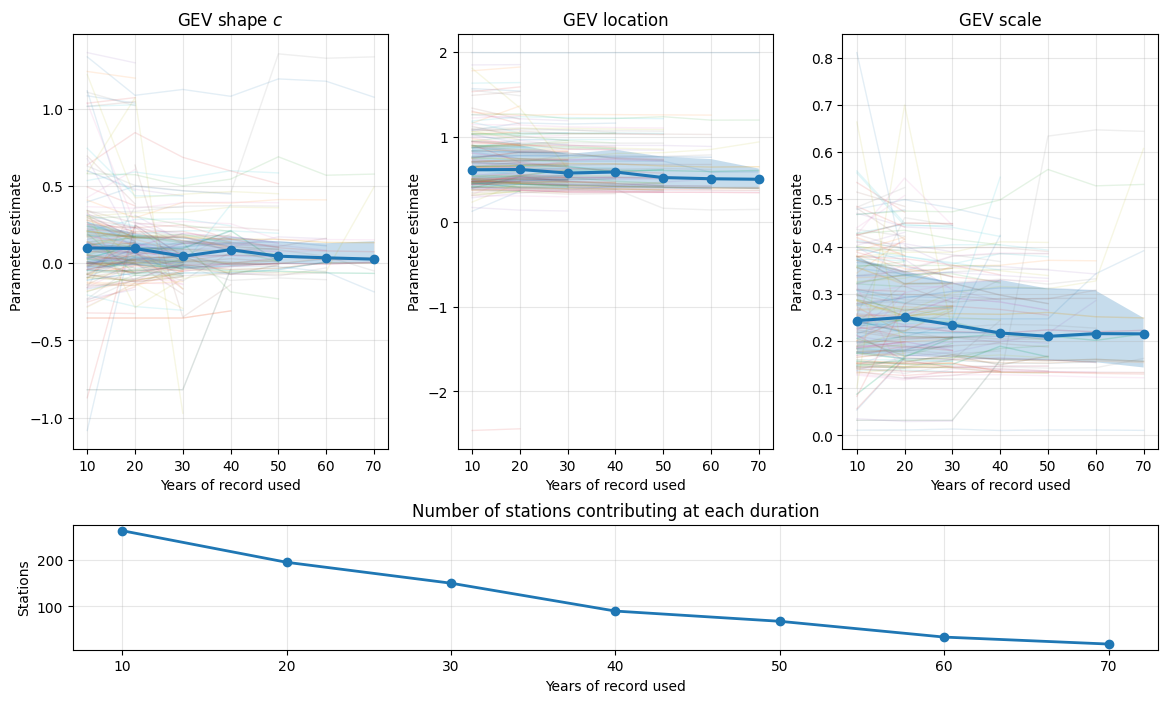

In [30]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[4, 1.2], hspace=0.28, wspace=0.22)

axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
ax_n = fig.add_subplot(gs[1, :])

specs = [
    ("gev_c", "gev_c_median", "gev_c_q25", "gev_c_q75", "GEV shape $c$"),
    ("gev_loc", "gev_loc_median", "gev_loc_q25", "gev_loc_q75", "GEV location"),
    ("gev_scale", "gev_scale_median", "gev_scale_q25", "gev_scale_q75", "GEV scale"),
]

for ax, (col, med, q25, q75, title) in zip(axes, specs):

    # faint individual station trajectories
    for station_id, g in df_stab.groupby("station"):
        g = g.sort_values("years_used")
        ax.plot(
            g["years_used"],
            g[col],
            linewidth=1.0,
            alpha=0.12
        )

    # IQR envelope
    ax.fill_between(
        summary["years_used"],
        summary[q25],
        summary[q75],
        alpha=0.25
    )

    # ensemble median
    ax.plot(
        summary["years_used"],
        summary[med],
        marker="o",
        linewidth=2.2
    )

    ax.set_title(title)
    ax.set_xlabel("Years of record used")
    ax.set_ylabel("Parameter estimate")
    ax.grid(alpha=0.3)

# number of stations panel
ax_n.plot(
    summary["years_used"],
    summary["n_stations"],
    marker="o",
    linewidth=2
)
ax_n.set_xlabel("Years of record used")
ax_n.set_ylabel("Stations")
ax_n.set_title("Number of stations contributing at each duration")
ax_n.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
for ax in axes + [ax_n]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# optional panel labels
for label, ax in zip(["a", "b", "c"], axes):
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=12, fontweight="bold"
    )

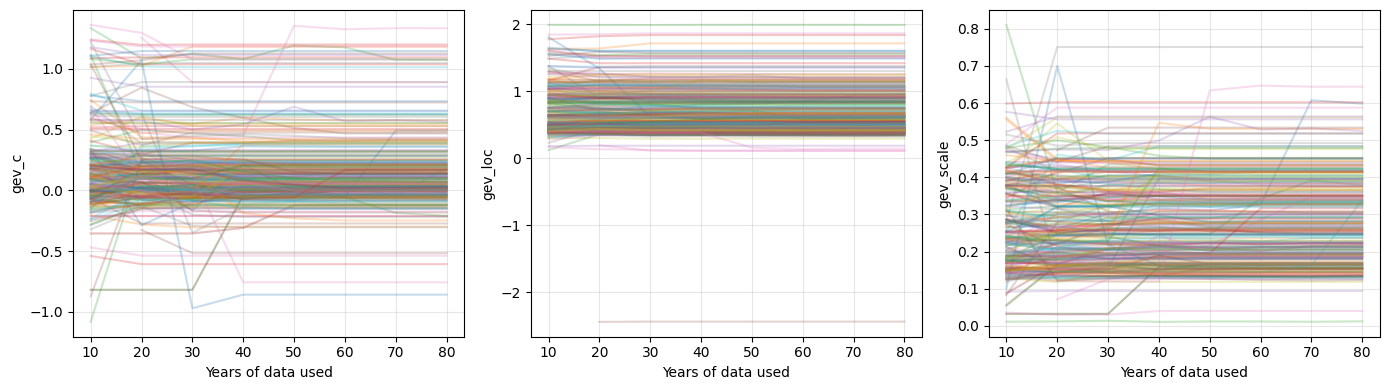

In [27]:
fig, axes = plt.subplots(1,3, figsize=(14,4))

params = ["gev_c","gev_loc","gev_scale"]

for i,p in enumerate(params):

    for s, g in df_stability.groupby("station"):
        axes[i].plot(g["years_used"], g[p], alpha=0.25)

    axes[i].set_xlabel("Years of data used")
    axes[i].set_ylabel(p)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# dataframe with common predictors